<a href="https://colab.research.google.com/github/ireneebiyekoa-commits/MEMOIRE/blob/main/MemoireIrenee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/ireneebiyekoa-commits/MEMOIRE/main/DATA_COMPLETE.xlsx"

response = requests.get(url)

df = pd.read_excel(BytesIO(response.content))

df.head()

,district,annee,mois,date,trimestre,cas_confirmes,deces_paludisme,temp_moy,humidite,precip_mensuel
0,District Bogo,2017,1,2017-01-01,T1,435.0,0.0,26.76,17.58,0.00
1,District Bogo,2017,2,2017-02-01,T1,343.0,1.0,26.55,11.62,0.00
2,District Bogo,2017,3,2017-03-01,T1,321.0,0.0,30.58,11.61,0.00
3,District Bogo,2017,4,2017-04-01,T2,245.0,1.0,34.47,23.37,1.80
4,District Bogo,2017,5,2017-05-01,T2,177.0,3.0,32.31,47.01,73.47


In [16]:
df.shape

(3456, 10)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3456 entries, 0 to 3455
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   district         3456 non-null   object        
 1   annee            3456 non-null   int64         
 2   mois             3456 non-null   int64         
 3   date             3456 non-null   datetime64[ns]
 4   trimestre        3456 non-null   object        
 5   cas_confirmes    3434 non-null   float64       
 6   deces_paludisme  2922 non-null   float64       
 7   temp_moy         3456 non-null   float64       
 8   humidite         3456 non-null   float64       
 9   precip_mensuel   3456 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(2)
memory usage: 270.1+ KB


In [18]:
df.head(4)

,district,annee,mois,date,trimestre,cas_confirmes,deces_paludisme,temp_moy,humidite,precip_mensuel
0,District Bogo,2017,1,2017-01-01,T1,435.0,0.0,26.76,17.58,0.0
1,District Bogo,2017,2,2017-02-01,T1,343.0,1.0,26.55,11.62,0.0
2,District Bogo,2017,3,2017-03-01,T1,321.0,0.0,30.58,11.61,0.0
3,District Bogo,2017,4,2017-04-01,T2,245.0,1.0,34.47,23.37,1.8


In [19]:
df["date"]     = pd.to_datetime(df["date"], errors = "coerce")
print("Dates invalides :", df["date"].isnull().sum())

Dates invalides : 0


In [20]:
df["district"] = df["district"].astype(str)
df             = df.sort_values(["district", "date"]).reset_index(drop=True)

In [21]:
# =============================================================================
# ETAPE 2 — IMPUTATION DES VALEURS MANQUANTES
# =============================================================================

def imputer_serie(series):
    s = series.interpolate(method="linear", limit_direction="both")

    if s.isnull().all():
        return s.fillna(0)

    return s.fillna(s.median())

# Cas confirmés (par district)
df["cas_confirmes"] = df.groupby("district")["cas_confirmes"].transform(imputer_serie)

# Décès (hypothèse documentaire à justifier)
df["deces_paludisme"] = df["deces_paludisme"].fillna(0)

# Vérification
print(df[["cas_confirmes", "deces_paludisme"]].isnull().sum())

cas_confirmes      0
deces_paludisme    0
dtype: int64


In [22]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

In [23]:
out_cas, low_cas, up_cas = detect_outliers_iqr(df, "cas_confirmes")
out_deces, low_dec, up_dec = detect_outliers_iqr(df, "deces_paludisme")

print(out_cas.shape, out_deces.shape)

(247, 10) (288, 10)


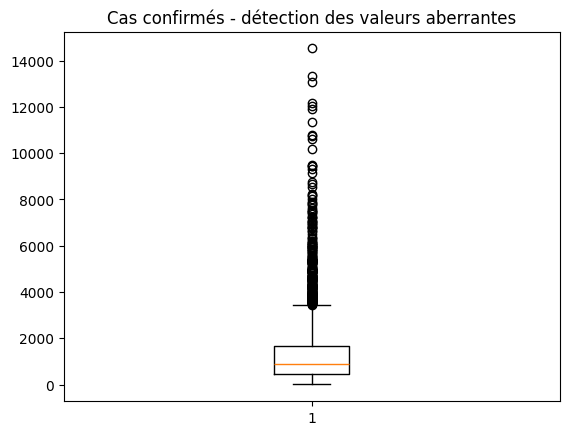

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df["cas_confirmes"])
plt.title("Cas confirmés - détection des valeurs aberrantes")
plt.show()

In [26]:
def add_outlier_flag(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col + "_outlier"] = (
        (df[col] < lower) | (df[col] > upper)
    ).astype(int)

    return df

In [27]:
df = add_outlier_flag(df, "cas_confirmes")
df = add_outlier_flag(df, "deces_paludisme")

In [28]:
df.head()

,district,annee,mois,date,trimestre,cas_confirmes,deces_paludisme,temp_moy,humidite,precip_mensuel,cas_confirmes_outlier,deces_paludisme_outlier
0,District Bogo,2017,1,2017-01-01,T1,435.0,0.0,26.76,17.58,0.00,0,0
1,District Bogo,2017,2,2017-02-01,T1,343.0,1.0,26.55,11.62,0.00,0,0
2,District Bogo,2017,3,2017-03-01,T1,321.0,0.0,30.58,11.61,0.00,0,0
3,District Bogo,2017,4,2017-04-01,T2,245.0,1.0,34.47,23.37,1.80,0,0
4,District Bogo,2017,5,2017-05-01,T2,177.0,3.0,32.31,47.01,73.47,0,0
